## Object Detection

### Sobel Edge Detection

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
def display(img):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111)
    ax.imshow(img, cmap='gray')
    ax.axis('off')

def create_img():
    blank_img = np.zeros((200, 200))
    font = cv2.FONT_HERSHEY_DUPLEX
    cv2.putText(img=blank_img,
               text='H',
               org=(50, 150),
               fontFace=font,
               fontScale=5,
               color=(255, 255, 255),
               thickness=25,
               lineType=cv2.LINE_AA)

    return blank_img

In [ ]:
i = create_img()
display(i)

In [ ]:
sobel_x = np.array([[-1, -2, -1],
                    [0, 0, 0],
                    [1, 2, 1]])

sobel_y = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

In [ ]:
edge_x = cv2.filter2D(src=i, ddepth=-1, kernel=sobel_x)
display(edge_x)

edge_x[edge_x != 0] = 255
display(edge_x)

In [ ]:
edge_y = cv2.filter2D(src=i, ddepth=-1, kernel=sobel_y)
display(edge_y)

edge_y[edge_y != 0] = 255
display(edge_y)

In [ ]:
add_edge = edge_x + edge_y
display(add_edge)

add_edge[add_edge != 0] = 255
display(add_edge)

## Canny Edge detection

1. Noise Reduction
2. Gradient Calculation
3. Non Maximum Suppression
4. Double Threshold
5. Edge Tracking by Hyesteresis

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal import convolve2d

In [ ]:
def display(img, title="Image"):
    plt.figure(figsize=(10, 8))
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

In [ ]:
sobel_y = np.array([[-1, -2, -1],
                    [0, 0, 0],
                    [1, 2, 1]])

sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

In [ ]:
def load_image(image_path):
    image = plt.imread(image_path)
    if image.ndim == 3:
        image = np.mean(image,axis=2)
    return image

In [ ]:
image_path = "g2.jpg"
image = load_image(image_path)
display(image,"Original Image")

In [ ]:
def gaussian_blur(image, sigma=1):
    return gaussian_filter(image, sigma=sigma)

blurred = gaussian_blur(image, sigma=2)
display(blurred, "Gaussian Blurred Image")

In [ ]:
def compute_gradients(image):
    grad_x = convolve2d(image, sobel_x, mode='same', boundary='wrap')
    grad_y = convolve2d(image, sobel_y, mode='same', boundary='wrap')

    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    direction = np.arctan2(grad_y, grad_x)

    return magnitude, direction

magnitude, direction = compute_gradients(blurred)
display(magnitude, "Gradient Magnitude")

In [ ]:
def non_max_suppression(magnitude, direction):
    M, N = magnitude.shape
    output = np.zeros((M, N), dtype=np.float32)
    angle = direction * 180 / np.pi

    angle[angle < 0] += 180

    for i in range(1, M-1):
        for j in range(1, N-1):
            # Get the direction of the gradient
            q = 255
            r = 255

            if 0 <= angle[i, j] < 22.5 or 157.5 <= angle[i, j] <= 180:
                q = magnitude[i, j+1]
                r = magnitude[i, j-1]

            elif 22.5 <= angle[i, j] < 67.5:
                q = magnitude[i+1, j-1]
                r = magnitude[i-1, j+1]

            elif 67.5 <= angle[i, j] < 112.5:
                q = magnitude[i+1, j]
                r = magnitude[i-1, j]

            elif 112.5 <= angle[i, j] < 157.5:
                q = magnitude[i-1, j-1]
                r = magnitude[i+1, j+1]

            if magnitude[i, j] >= q and magnitude[i, j] >= r:
                output[i, j] = magnitude[i, j]
            else:
                output[i, j] = 0

    return output

suppressed = non_max_suppression(magnitude, direction)
display(suppressed, "Non-Maximum Suppression")

In [ ]:
def double_threshold(image, low_threshold, high_threshold):
    strong = 255
    weak = 75
    result = np.zeros_like(image, dtype=np.float32)

    result[image >= high_threshold] = strong
    result[(image >= low_threshold) & (image < high_threshold)] = weak

    return result

thresholded = double_threshold(suppressed, low_threshold=10, high_threshold=20)
display(thresholded, "Double Threshold")

In [ ]:
def edge_tracking_by_hysteresis(image):
    M, N = image.shape
    result = np.copy(image)
    strong_rows, strong_cols = np.where(image == 255)

    for i, j in zip(strong_rows, strong_cols):
        for x in range(-1, 2):
            for y in range(-1, 2):
                if 0 <= i+x < M and 0 <= j+y < N:
                    if image[i+x, j+y] == 75:
                        result[i+x, j+y] = 255

    return result

def enhance_contrast(image, factor=2.0):
    return np.clip(image * factor, 0, 255)

edges = edge_tracking_by_hysteresis(thresholded)
edges = enhance_contrast(edges, factor=2.0)
display(edges, "Final Edges")

## Template Matching

In [ ]:
image = cv2.imread('image/f16.png')
template = cv2.imread('image/template.png')

In [ ]:
image_rgb = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)

In [ ]:
image_gray = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
template_gray = cv2.cvtColor(template,cv2.COLOR_BGR2GRAY)

In [ ]:
w,h = template_gray.shape[::-1]

In [ ]:
plt.imshow(image_gray,cmap='gray')

In [ ]:
plt.imshow(template_gray,cmap='gray')

In [ ]:
result = cv2.matchTemplate(image, template,cv2.TM_SQDIFF)
result

In [ ]:
plt.imshow(result, cmap='gray')

In [ ]:
min_val,max_val, min_loc,max_loc=cv2.minMaxLoc(result)

In [ ]:
min_loc

In [ ]:
top_left=min_loc

bottom_right = (top_left[0]+w,top_left[1]+h)

In [ ]:
image=cv2.rectangle(image,top_left,bottom_right,(0,0,255),2)
image_rgb = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 10))
plt.imshow(image_rgb)
plt.title("Matched Image")
plt.axis('off')  # Hide the axis
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

result = cv2.matchTemplate(image_gray, template_gray, cv2.TM_CCOEFF_NORMED)

threshold = 0.5
loc = np.where(result >= threshold)

for pt in zip(*loc[::-1]):
    cv2.rectangle(image, pt, (pt[0] + w, pt[1] + h), (0, 0, 255), 1)

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(image_rgb)
plt.title('Matched Image with Multiple Objects')
plt.axis('off')
plt.show()

## Modern Object Detection

### Faster RCNN

In [1]:
import torch
from torchvision import models, transforms
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

In [2]:
model = models.detection.fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()

c:\Users\Muhammad Afiq\anaconda3\envs\python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Muhammad Afiq\anaconda3\envs\python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\Muhammad Afiq/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100.0%


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

In [7]:
COCO_LABELS = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train',
    'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter',
    'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear',
    'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase',
    'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat',
    'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle',
    'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
    'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut',
    'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', ' toilet',
    'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave',
    'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors',
    'teddy bear', 'hair drier', 'toothbrush'
]

In [35]:
image_path =  'image\husky.jpg'
image = Image.open(image_path).convert("RGB")


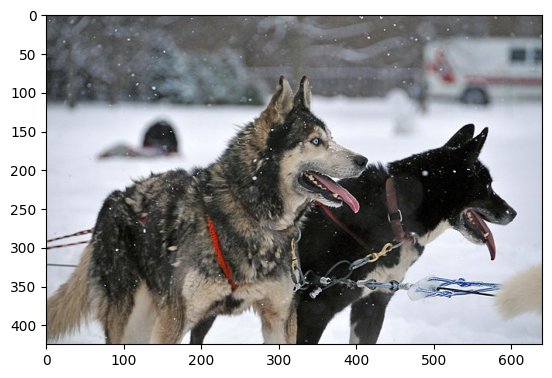

In [36]:
plt.imshow(image)

In [37]:
import torch
import torchvision.transforms as transforms
from PIL import ImageFont, ImageDraw

transform = transforms.Compose([
    transforms.ToTensor()
])

img_tensor = transform(image).unsqueeze(0)

with torch.no_grad():
    predictions = model(img_tensor)

In [38]:
pred_boxes = predictions[0]['boxes'].cpu().numpy()
pred_labels = predictions[0]['labels'].cpu().numpy()
pred_scores = predictions[0]['scores'].cpu().numpy()

In [39]:
threshold = 0.5
filtered_boxes = pred_boxes[pred_scores > threshold]
filtered_labels = pred_labels[pred_scores > threshold]
filtered_scores = pred_scores[pred_scores >= threshold]

In [40]:
draw = ImageDraw.Draw(image)
font = ImageFont.truetype("arial.ttf", size=24)

for box, label, score in zip(filtered_boxes, filtered_labels, filtered_scores):
    x0, y0, x1, y1 = box
    label_name = COCO_LABELS[label - 1]

    draw.rectangle([x0, y0, x1, y1], outline="red", width=3)

    text = f"{label_name} ({score:.2f})"
    draw.text((x0, y0), text, fill="red", font=font)

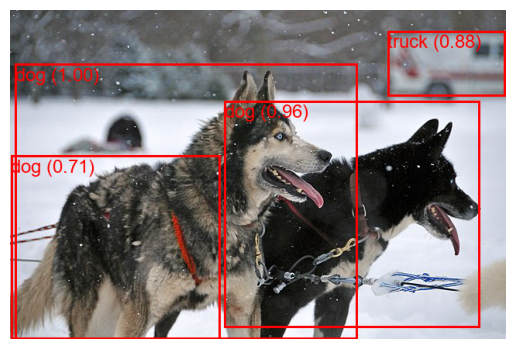

In [41]:
plt.imshow(image)
plt.axis('off')
plt.show()

## YOLO v8

In [53]:
from ultralytics import YOLO

model = YOLO("yolov8x.pt")
results = model("image/cat_and_dog.jpg")

100.0%



image 1/1 d:\Coding_Project\Peoplelogy_DataScience\notebook\Week_7\image\cat_and_dog.jpg: 480x640 1 cat, 1 dog, 558.2ms
Speed: 3.0ms preprocess, 558.2ms inference, 0.0ms postprocess per image at shape (1, 3, 480, 640)


In [54]:
res_plotted = results[0].plot()

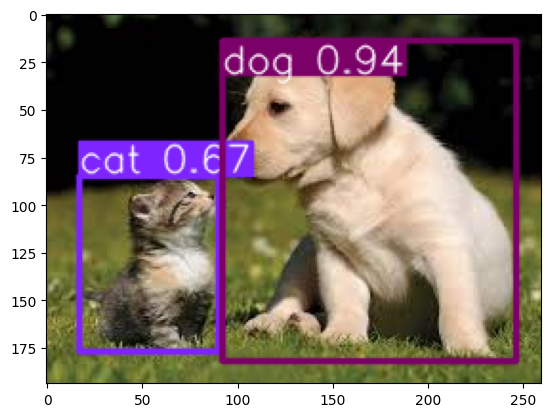

In [55]:
import matplotlib.pyplot as plt
import cv2
plt.imshow(cv2.cvtColor(res_plotted,cv2.COLOR_BGR2RGB))